In [ ]:
#Amit pawar
#prn:25070126501
#Random forest this assignmet use a global_fuel_prices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/global_fuel_prices_2020_2026.csv")
df.head()


,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [3]:
df.sum().isnull()

,0
date,False
country,False
region,False
income_level,False
subsidy_level,False
petrol_usd_liter,False
diesel_usd_liter,False
lpg_usd_liter,False
brent_crude_usd,False
tax_percentage,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [5]:
if 'Employee ID' in df.columns:
    df = df.drop('Employee ID', axis=1)

In [6]:
df.head(2)

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6


In [7]:
label_encoders = {}
for col in df.select_dtypes(include=['object']):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


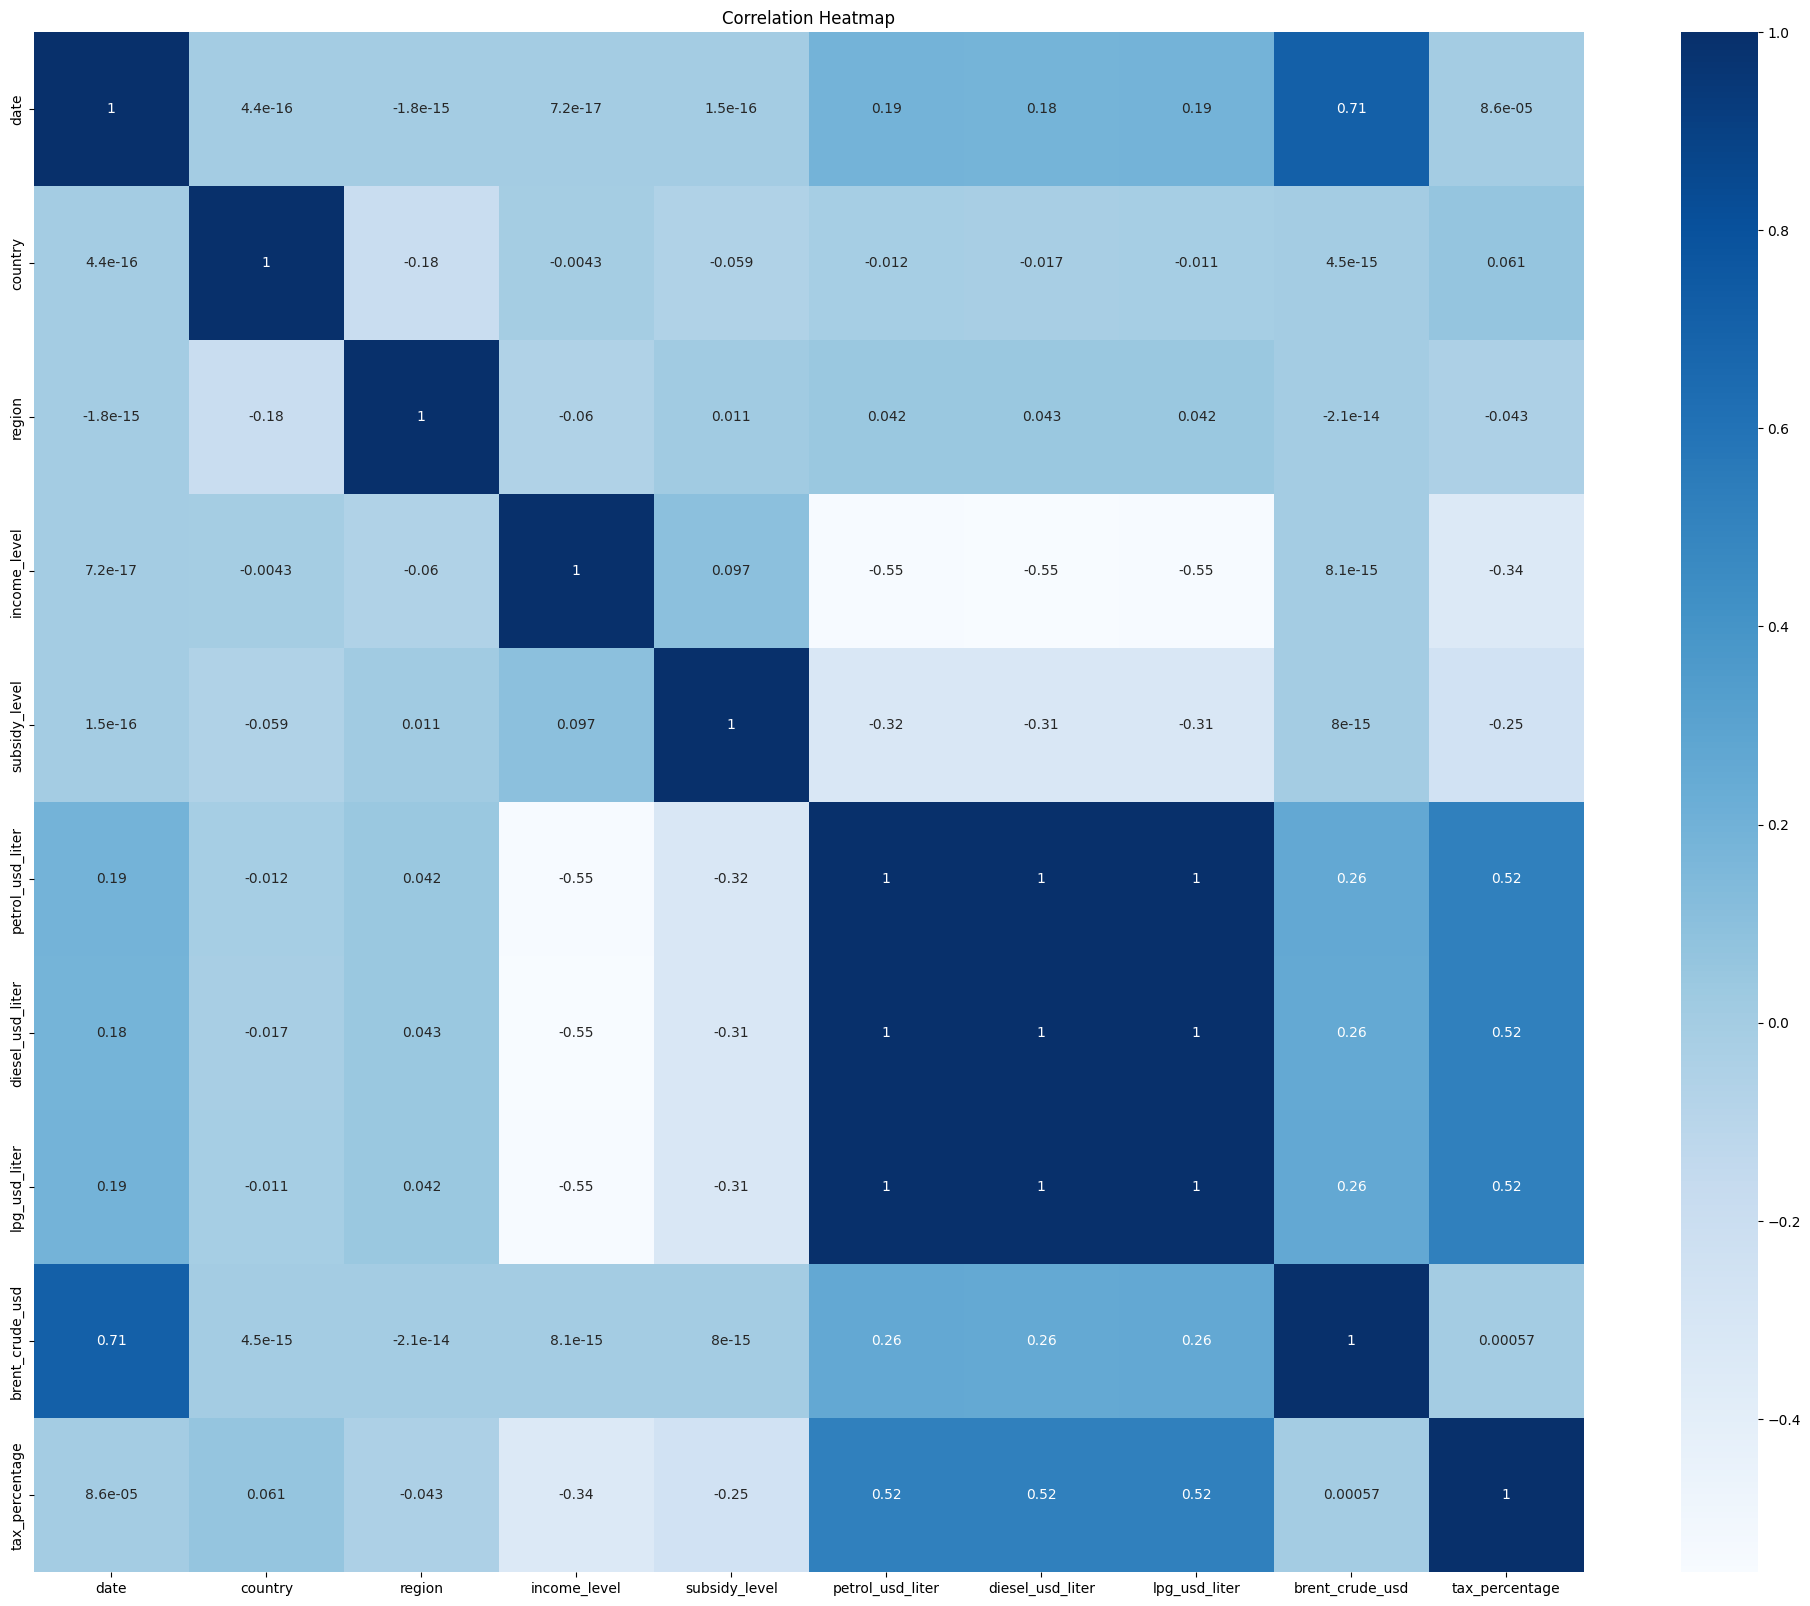

In [8]:
plt.figure(figsize=(25, 20))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
X = df.drop(columns=['petrol_usd_liter'])
y = df['petrol_usd_liter']

In [12]:
from imblearn.over_sampling import SMOTE

# Convert the continuous 'petrol_usd_liter' into discrete categories for classification
# You can adjust the number of bins and labels as per your problem definition.
y_binned = pd.cut(y, bins=5, labels=False, include_lowest=True)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_binned)

print("before:\n" , y_binned.value_counts())
print("after:\n" , y_resampled.value_counts())

before:
 petrol_usd_liter
1    9261
0    8506
2    4886
3    4448
4     367
Name: count, dtype: int64
after:
 petrol_usd_liter
1    9261
0    9261
2    9261
3    9261
4    9261
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.model_selection import GridSearchCV

params ={
  'n_estimators':[50, 100 ],
  'max_depth':[5, 10, None]

}
grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.9954108627578014


In [15]:
params= {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
grid= GridSearchCV(RandomForestClassifier(), params, cv= 3)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]})

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1852
           1       0.99      0.99      0.99      1852
           2       0.99      0.99      0.99      1852
           3       1.00      0.99      1.00      1853
           4       1.00      1.00      1.00      1852

    accuracy                           1.00      9261
   macro avg       1.00      1.00      1.00      9261
weighted avg       1.00      1.00      1.00      9261



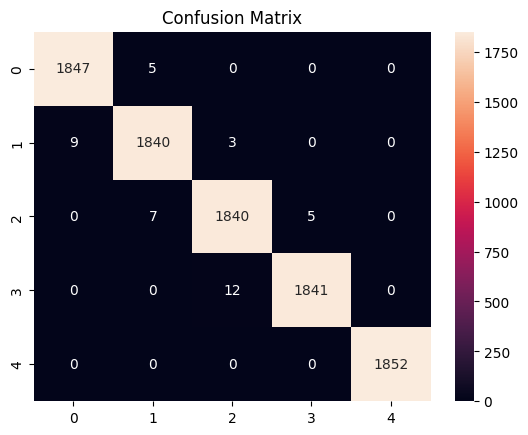

In [16]:
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, fmt= 'd')
plt.title('Confusion Matrix')
plt.show()

In [17]:
y_pred= best_rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, cmap= 'Blues', fmt= 'd')
plt.title('Confusion Matrix')
plt.show()

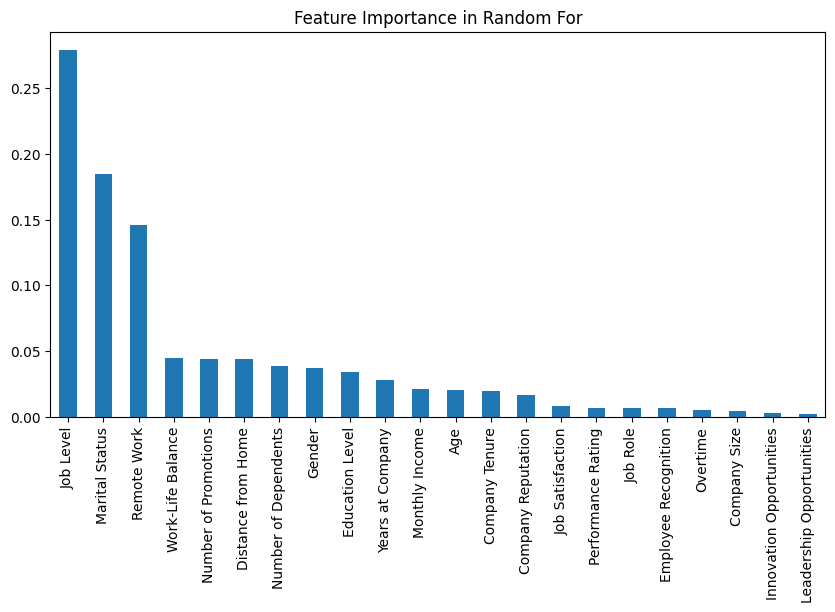

In [ ]:
feature_importance= pd.Series(best_rf.feature_importances_, index= df.drop(columns= ['Attrition']).columns)
feature_importance.sort_values(ascending= False).plot(kind= 'bar', figsize= (10, 5), title= 'Feature Importance in Random For')
plt.show()

In [18]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

#AdaBoost Classsifcation
adaboost = AdaBoostClassifier(n_estimators= 100, learning_rate=0.5, random_state= 42)
adaboost.fit(X_train_scaled, y_train)

#Gradient Boosting
gridboost =  GradientBoostingClassifier(n_estimators= 100, learning_rate=0.5, random_state= 42)
gridboost.fit(X_train_scaled, y_train)

model = {
  "Random  Forest": best_rf,
  "AdaBoost": adaboost,
  "Gradient Boosting": gridboost
}
for name, model in model.items():
  print(f"\n{name} performance:")
  y_pred = model.predict(X_test_scaled)
  accuracy = accuracy_score(y_test,y_pred)
  print(f"Accuracy: {accuracy:.4f}")


Random  Forest performance:
Accuracy: 0.9956

AdaBoost performance:
Accuracy: 0.7958

Gradient Boosting performance:
Accuracy: 0.9945


Confusion Matrix:
[[1848    4    0    0    0]
 [  11 1835    6    0    0]
 [   0    9 1833   10    0]
 [   0    0    9 1844    0]
 [   0    0    0    2 1850]]


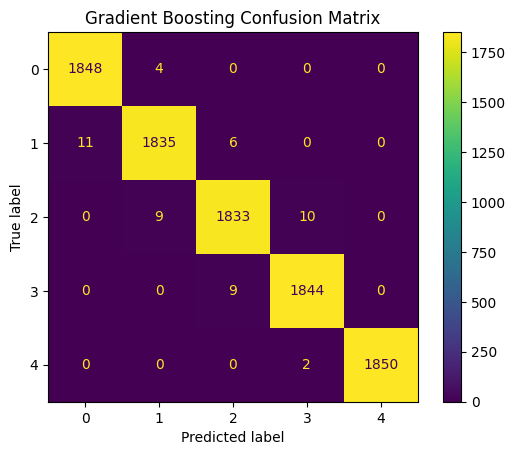

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"{name} Confusion Matrix")
plt.show()

/tmp/ipykernel_1109/3426745799.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Random Classifier')


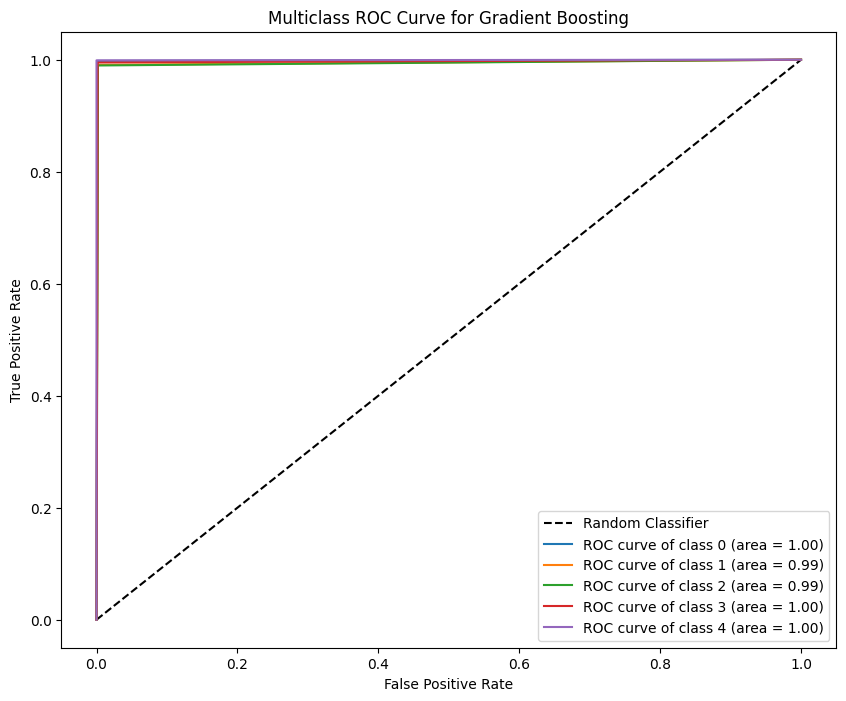

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming y_test and y_pred are already available and are multiclass labels

n_classes = len(np.unique(y_test))

# Binarize the true and predicted labels for OvR
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_pred_bin = label_binarize(y_pred, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', linestyle='--', label='Random Classifier')

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multiclass ROC Curve for {name}')
plt.legend(loc='lower right')
plt.show()